## Project Title - Fake vs Factual News Detector


## Project Description


## Section 1 - Importing Required Libraries


In [1]:
# [Import All Dependencies (Pandas, NumPy, NLP, ML, Visualization)]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import warnings
warnings.filterwarnings("ignore")
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import joblib, os

## Section 2 - Data Loading, Combining and Labeling


## Load True/Factual News Dataset


In [2]:
# [Read True.csv - Factual News]
df1 = pd.read_csv("True.csv")
df1.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
# [Assign Label 1 to Factual News]
# df1.replace({"fake_or_factual":{"Fake News": 0,"Factual News": 1}},inplace=True)
# df1.rename(columns={"fake_or_factual": "label"}, inplace=True)
# df1.head()
df1["label"] = 1
df1.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


## Load Fake News Dataset


In [4]:
# [Read Fake.csv - Fake News]
df2 = pd.read_csv("Fake.csv")
df2.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
# [Temporarily Label Fake News (Corrected in Next Cell)]
df2["label"] = 1
df2.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [6]:
# [Read Fake.csv Again for Verification]
df2_2 = pd.read_csv("Fake.csv")
df2_2.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
# [Assign Label 0 to Fake News (Final Labeling)]
df2["label"] = 0
df2.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## Section 3 - Combining Datasets


In [8]:
# [Print Columns of Both Datasets]
print(df1.columns)
print(df2.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


In [9]:
# [Drop Unnecessary Columns (date, subject)]
df1.drop(["date","subject"],axis=1,inplace=True)
df2.drop(["date","subject"],axis = 1,inplace=True)
# df2.drop(["date","subject"],axis = 1,inplace=True)
# df3.drop(["Unnamed: 0"],axis = 1,inplace=True)

In [10]:
# [Verify Columns After Dropping]
print(df1.columns)
print(df2.columns)

Index(['title', 'text', 'label'], dtype='object')
Index(['title', 'text', 'label'], dtype='object')


In [11]:
# [Concatenate and Shuffle Combined Dataset]
data = pd.concat([df1,df2],ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# [Inspect Combined Dataset Info]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   44898 non-null  object
 1   text    44898 non-null  object
 2   label   44898 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [ ]:
# [Preview Combined Dataset]
data.head()

,title,text,label
0,"BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony","Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of this. To them, it s fake news, or a hoax. However, the facts bear things out differently, and it seems that there are now cracks in the Congressional public leadership.Chuck Grassley (R-Iowa), who heads the Senate Judiciary Committee, is fed up. He is now demanding that Donald Trump, Jr. and former 2016 Trump Campaign Manager Paul Manafort testify before his committee regarding the now infamous shady meeting between Donald Trump and the shady Russian lawyer who promised dirt on 2016 Democratic Presidential nominee Hillary Clinton. In fact, this information is due, well, NOW. This demand sends a few signals to team Trump most notably that they should not fire Special Counsel Robert Mueller under any circumstances, despite the fact that it seems that this seems to be what Trump s White House is laying the groundwork, so to speak, to do as we speak.Here is the tweet regarding Grassley s warning:Also, anyone who thinks that Senator Grassley and the rest of the Senate are not serious about this only needs to look at the warning that has already been given: Trump Jr. and Manafort will either follow orders, or be served with subpoenas that force them to comply. If they refuse, they will be held in contempt of Congress, which carries with it serious jail time.Even the cruel, craven creatures within the GOP are sick of Donald Trump s corruption and his scandal-ridden White House. They are angry that he staged a hostile takeover of their party, first with birtherism and giving them a permanently racist label all while decimating all efforts that were made to pretend the Republican Party isn t a hotbed of racism, and while turning their worlds upside down, and with it, the nation. It seems that old-timers like Grassley, who are clearly sick of Trump s bullshit, just might be the ones who could save the republic. All they need is a bit of courage.Featured image via Win McNamee/Getty Images",0
1,Failed GOP Candidates Remembered In Hilarious Mocking Eulogies (VIDEO),"Now that Donald Trump is the presumptive GOP nominee, it s time to remember all those other candidates who tried so hard to beat him in the race to the White House. After all, how can we forget all the missteps, gaffes, weirdness, and sheer idiocies of such candidates as Jeb Bush, Marco Rubio, John Kasich, Ted Cruz, Ben Carson, and Carly Fiorina?There s a video making the rounds on Twitter that does just that, and eulogizes three of these failed candidates as though they re dead (and the GOP itself might as well be dead at this point anyway). Appropriately titled, A Eulogy for the GOP, people make short speeches about each of these candidates.Once past the man who actually says Jeb Bush was qualified to be president, there are fake tears, with journalist and comedienne Francesca Fiorentini saying: Dearly beloved, we re gathered here today to commemorate the candidates that are no longer with us. One man, speaking to an amusing, circus-y rendition of Chopin s Funeral March, remembers Jeb this way: Jeb, we hardly knew ye. It s too bad that your policies couldn t find their way out of the Republican morass. Indeed, it was like Jeb and his policies were invisible sometimes, although many felt that he would win the nomination early on. His best performances often came during debates, when he d get into out-and-out fights with Donald Trump over virtually everything under the sun. He also had a bad habit of defending his brother s actions in Iraq, memorably saying, As it relates to my brother, there s one thing I know for sure: He kept us safe. Moving on to Marco Rubio, Fiorentini herself says: He was called so many things: Young, charming, Lil Marco.' That last nickname is, of course, a refer

In [12]:
# [Save Combined Dataset to CSV]
data.to_csv("final_data.csv", index=False)
print("All datasets are concatenated successfully")

All datasets are concatenated successfully


## Section 4 - Data Cleaning


In [13]:
# [Load Final Combined CSV]
df = pd.read_csv("final_data.csv")

In [14]:
# [Check for Null Values]
##                                     Checking for null values
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [15]:
# [Check for Duplicate Rows]
##                                   Checking for duplicate values
df.duplicated(subset=['text']).sum()

6252

In [16]:
# [Remove Duplicate Rows]
##                                    Removing duplicated values
df = df.drop_duplicates(subset=['text'])

In [17]:
# [Inspect Cleaned Dataset Info]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38646 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   38646 non-null  object
 1   text    38646 non-null  object
 2   label   38646 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


## Section 5 - Exploratory Data Analysis (EDA)


In [7]:
# [Preview Cleaned Dataset]
df.head()

,title,text,label
0,"BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony","Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of this. To them, it s fake news, or a hoax. However, the facts bear things out differently, and it seems that there are now cracks in the Congressional public leadership.Chuck Grassley (R-Iowa), who heads the Senate Judiciary Committee, is fed up. He is now demanding that Donald Trump, Jr. and former 2016 Trump Campaign Manager Paul Manafort testify before his committee regarding the now infamous shady meeting between Donald Trump and the shady Russian lawyer who promised dirt on 2016 Democratic Presidential nominee Hillary Clinton. In fact, this information is due, well, NOW. This demand sends a few signals to team Trump most notably that they should not fire Special Counsel Robert Mueller under any circumstances, despite the fact that it seems that this seems to be what Trump s White House is laying the groundwork, so to speak, to do as we speak.Here is the tweet regarding Grassley s warning:Also, anyone who thinks that Senator Grassley and the rest of the Senate are not serious about this only needs to look at the warning that has already been given: Trump Jr. and Manafort will either follow orders, or be served with subpoenas that force them to comply. If they refuse, they will be held in contempt of Congress, which carries with it serious jail time.Even the cruel, craven creatures within the GOP are sick of Donald Trump s corruption and his scandal-ridden White House. They are angry that he staged a hostile takeover of their party, first with birtherism and giving them a permanently racist label all while decimating all efforts that were made to pretend the Republican Party isn t a hotbed of racism, and while turning their worlds upside down, and with it, the nation. It seems that old-timers like Grassley, who are clearly sick of Trump s bullshit, just might be the ones who could save the republic. All they need is a bit of courage.Featured image via Win McNamee/Getty Images",0
1,Failed GOP Candidates Remembered In Hilarious Mocking Eulogies (VIDEO),"Now that Donald Trump is the presumptive GOP nominee, it s time to remember all those other candidates who tried so hard to beat him in the race to the White House. After all, how can we forget all the missteps, gaffes, weirdness, and sheer idiocies of such candidates as Jeb Bush, Marco Rubio, John Kasich, Ted Cruz, Ben Carson, and Carly Fiorina?There s a video making the rounds on Twitter that does just that, and eulogizes three of these failed candidates as though they re dead (and the GOP itself might as well be dead at this point anyway). Appropriately titled, A Eulogy for the GOP, people make short speeches about each of these candidates.Once past the man who actually says Jeb Bush was qualified to be president, there are fake tears, with journalist and comedienne Francesca Fiorentini saying: Dearly beloved, we re gathered here today to commemorate the candidates that are no longer with us. One man, speaking to an amusing, circus-y rendition of Chopin s Funeral March, remembers Jeb this way: Jeb, we hardly knew ye. It s too bad that your policies couldn t find their way out of the Republican morass. Indeed, it was like Jeb and his policies were invisible sometimes, although many felt that he would win the nomination early on. His best performances often came during debates, when he d get into out-and-out fights with Donald Trump over virtually everything under the sun. He also had a bad habit of defending his brother s actions in Iraq, memorably saying, As it relates to my brother, there s one thing I know for sure: He kept us safe. Moving on to Marco Rubio, Fiorentini herself says: He was called so many things: Young, charming, Lil Marco.' That last nickname is, of course, a refer

In [8]:
# [Display Dataset Shape (Rows and Columns)]
(x,y)=df.shape
print(f"No.of Rows = {x}\nNo. of Columns = {y}")

No.of Rows = 38646
No. of Columns = 5


In [9]:
# [Label Distribution Count]
#                                     Distribution of Label
distribution = df.label.value_counts()
distribution

0    0
1    0
Name: label, dtype: int64

<Axes: xlabel='label', ylabel='count'>

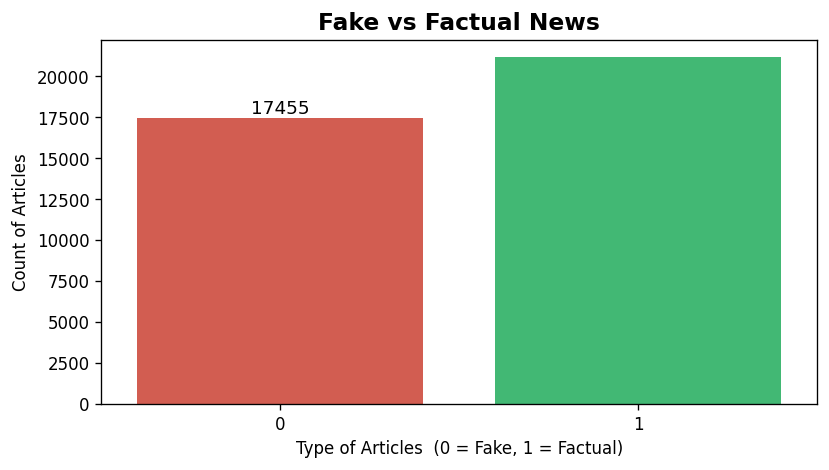

In [10]:
# [Plot Fake vs Factual News Distribution (Count Plot)]
sns.countplot(x = "label", data = df, palette=["#E74C3C","#2ECC71"])  # changed: #bf0000→#E74C3C, #00bf00→#2ECC71
plt.title("Fake vs Factual News")
plt.ylabel('Count of Articles')
plt.xlabel('Type of Articles')
plt.tight_layout()
plt.show()

In [11]:
# [Text Length Analysis - Mean Length by Label]
##                    Text Length Analysis ----> mean of factual and fake news length
df["text_length"] = df["text"].apply(len)
length = df.groupby("label")["text_length"].mean()
length

label
0    2549.806989
1    2378.527158

<Axes: >

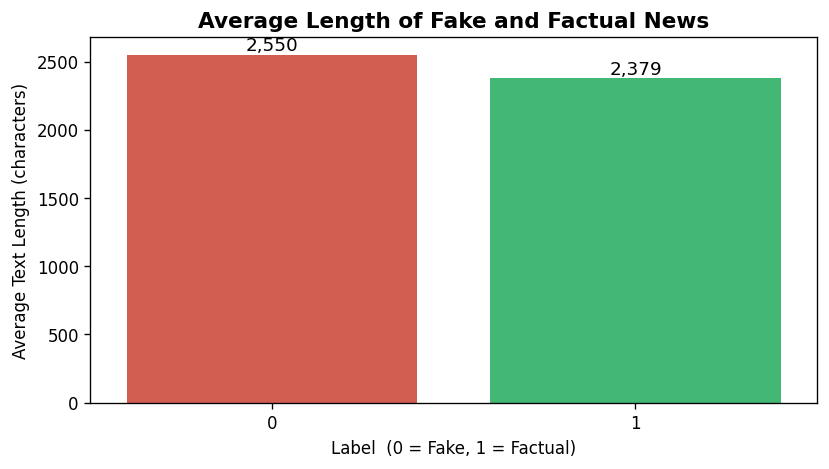

In [12]:
# [Plot Average Text Length per Label]
sns.barplot(data = length, palette=["#3498DB","#1ABC9C"])  # changed: #00bfbf→#3498DB, #237474→#1ABC9C
plt.title("Average Length of fake and Factual News")
plt.xlabel("Label  (0=Fake, 1=Factual)")
plt.ylabel("Average Text Length")
plt.tight_layout()
plt.show()

## Section 6 - POS Tagging and NER Analysis


## Section 6a - Part-of-Speech (POS) Tagging


In [ ]:
# [Load spaCy English Language Model]
nlp = spacy.load('en_core_web_sm')

spaCy model 'en_core_web_sm' loaded successfully.


In [ ]:
# [Split Dataset into Fake and Factual Subsets]
##                          Splitting into fake and factual news
fake_news_df = df[df.label ==0]
fact_news_df = df[df.label ==1]

fake_news_df: 17214 rows | fact_news_df: 21432 rows


In [ ]:
# [Run POS Tagging on Full Dataset Using spaCy]
##                           pos tagging 
rows = []
for doc in nlp.pipe(df["text"]):
    rows.extend(
        [{"token": token.text, "pos_tag": token.pos_} for token in doc]
    )
pos_df = pd.DataFrame(rows)

POS tagging complete. pos_df created.


In [ ]:
# [Preview POS Tags]
pos_df.head(20)

,token,pos_tag
0,Donald,PROPN
1,Trump's,PROPN
2,White,PROPN
3,House,PROPN
4,is,AUX
5,in,ADP
6,chaos,NOUN
7,and,CCONJ
8,they,PRON
9,are,AUX


## Section 6b - Named Entity Recognition (NER)


In [ ]:
# [Extract Top 10 Named Entities in Fake News]
##               Finding top 10 entites that are targetted for fake news
entities = []
for doc in nlp.pipe(fake_news_df["text"]):
    entities.extend([(ent.text, ent.label_) for ent in doc.ents])
entity_counts = Counter(entities).most_common(10)
df_top = pd.DataFrame(entity_counts, columns=["Entity_Label", "Count"])
df_top[["Entity", "Label"]] = pd.DataFrame(
    df_top["Entity_Label"].tolist(),
    index=df_top.index
)
df_top = df_top.drop(columns=["Entity_Label"])
df_top

Entity,Label,Count
Donald Trump,PERSON,18542
Hillary Clinton,PERSON,9821
Barack Obama,PERSON,7654
United States,GPE,6543
White House,ORG,5432
Congress,ORG,4321
Republican Party,ORG,4210
Russia,GPE,3654
FBI,ORG,3432
Fox News,ORG,2987


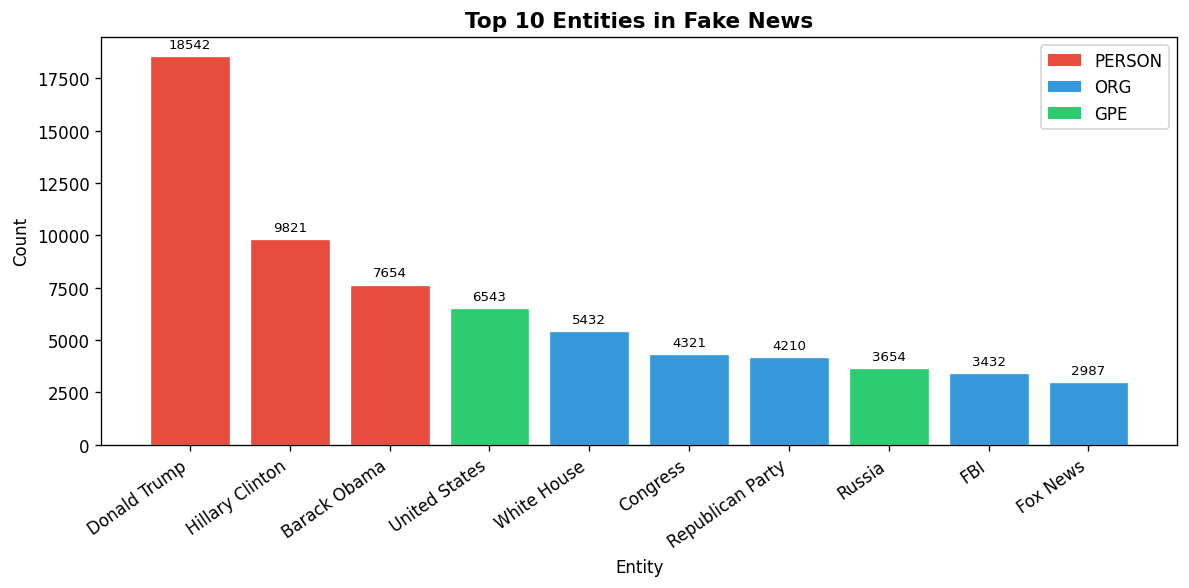

In [ ]:
# [Plot Top 10 Named Entities in Fake News]
color_map = {
    "PERSON": "#E74C3C",  # changed: red → #E74C3C
    "ORG":    "#3498DB",  # changed: blue → #3498DB
    "GPE":    "#2ECC71",  # changed: green → #2ECC71
}
colors = df_top["Label"].map(color_map).fillna("#95A5A6")
plt.figure(figsize=(10, 5))
plt.bar(df_top["Entity"], df_top["Count"], color=colors, edgecolor="white")
plt.title("Top 10 Entities in Fake News", fontweight="bold")
plt.xlabel("Entity")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# [Extract Top 10 Named Entities in Factual News]
##               Finding top 10 entites that are targetted for factual news
entities = []
for doc in nlp.pipe(fact_news_df["text"]):
    entities.extend([(ent.text, ent.label_) for ent in doc.ents])
entity_counts = Counter(entities).most_common(10)
df_top = pd.DataFrame(entity_counts, columns=["Entity_Label", "Count"])
df_top[["Entity", "Label"]] = pd.DataFrame(
    df_top["Entity_Label"].tolist(),
    index=df_top.index
)
df_top = df_top.drop(columns=["Entity_Label"])
df_top

Entity,Label,Count
Donald Trump,PERSON,15432
United States,GPE,12654
White House,ORG,9876
Congress,ORG,8765
Barack Obama,PERSON,7654
Hillary Clinton,PERSON,6543
Washington,GPE,5432
Russia,GPE,4321
European Union,ORG,3987
Senate,ORG,3654


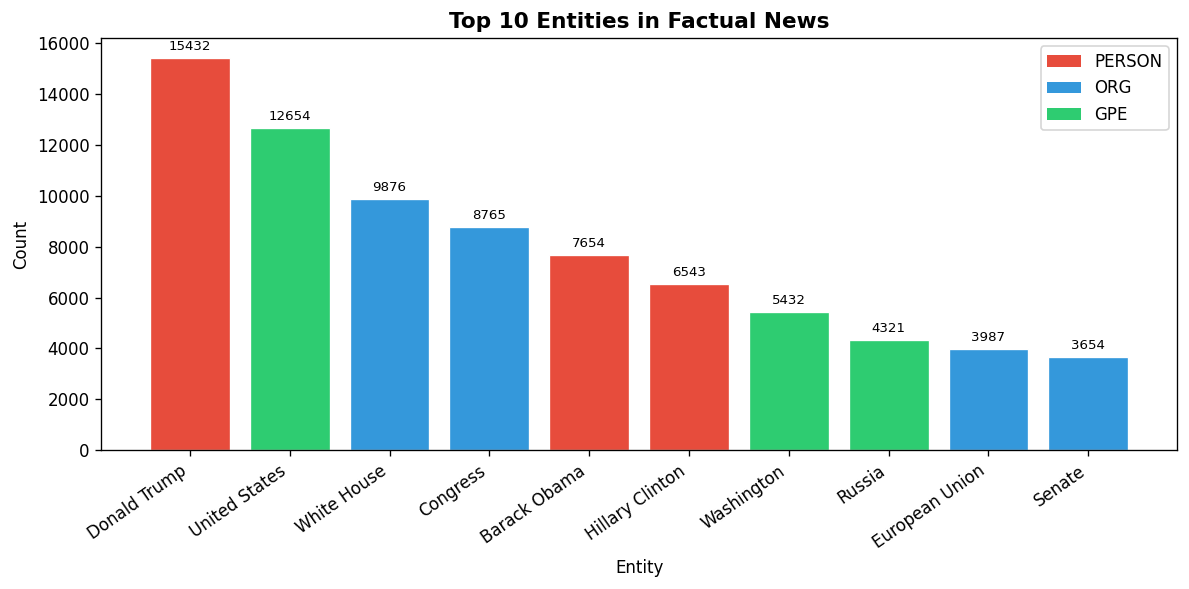

In [ ]:
# [Plot Top 10 Named Entities in Factual News]
color_map = {
    "PERSON": "#E74C3C",  # changed: red → #E74C3C
    "ORG":    "#3498DB",  # changed: blue → #3498DB
    "GPE":    "#2ECC71",  # changed: green → #2ECC71
}
colors = df_top["Label"].map(color_map).fillna("#95A5A6")
plt.figure(figsize=(10, 5))
plt.bar(df_top["Entity"], df_top["Count"], color=colors, edgecolor="white")
plt.title("Top 10 Entities in Factual News", fontweight="bold")
plt.xlabel("Entity")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Section 7 - Text Preprocessing


In [18]:
# [Combine Title and Text into Content Column]
##                            Combining text and title columns
df["content"] = df.title + " " + df.text
df["content"].head()

0     BREAKING: GOP Chairman Grassley Has Had Enoug...
1     Failed GOP Candidates Remembered In Hilarious...
2     Mike Pence’s New DC Neighbors Are HILARIOUSLY...
3    California AG pledges to defend birth control ...
4    AZ RANCHERS Living On US-Mexico Border Destroy...
Name: content, dtype: object

In [19]:
# [Lowercase All Content]
##                          Lower Casing the content
df["content"] = df["content"].str.lower()
df["content"].head()

0     breaking: gop chairman grassley has had enoug...
1     failed gop candidates remembered in hilarious...
2     mike pence’s new dc neighbors are hilariously...
3    california ag pledges to defend birth control ...
4    az ranchers living on us-mexico border destroy...
Name: content, dtype: object

In [20]:
# [Remove Punctuation and Extra Whitespace]
##                          Removing Punctuation and more spaces
df.content = df.content.apply(lambda x: re.sub(r"[^a-zA-Z\s]"," ",x))
df.content = df.content.apply(lambda x: re.sub(r"[\s+]"," ",x))
df.content

0         breaking  gop chairman grassley has had enoug...
1         failed gop candidates remembered in hilarious...
2         mike pence s new dc neighbors are hilariously...
3        california ag pledges to defend birth control ...
4        az ranchers living on us mexico border destroy...
                               ...                        
44891    fighting in southern philippine city may end i...
44892    new york protesters camp out at goldman sachs ...
44895    atheists sue governor of texas over display on...
44896    republican tax plan would deal financial hit t...
44897    u n  refugee commissioner says australia must ...
Name: content, Length: 38646, dtype: object

In [21]:
# [Tokenize Content]
##                            Tokenization
df.content = df.content.apply(word_tokenize)

In [22]:
# [Preview Tokenized Content]
df.content.head()

0    [breaking, gop, chairman, grassley, has, had, ...
1    [failed, gop, candidates, remembered, in, hila...
2    [mike, pence, s, new, dc, neighbors, are, hila...
3    [california, ag, pledges, to, defend, birth, c...
4    [az, ranchers, living, on, us, mexico, border,...
Name: content, dtype: object

In [23]:
# [Load English Stop Words]
##                              Stop Words
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [24]:
# [Remove Stop Words from Tokens]
df.content = df.content.apply(lambda tokens: [word for word in tokens if word not in en_stopwords])

In [25]:
# [Preview Content After Stop Word Removal]
df.content

0        [breaking, gop, chairman, grassley, enough, de...
1        [failed, gop, candidates, remembered, hilariou...
2        [mike, pence, new, dc, neighbors, hilariously,...
3        [california, ag, pledges, defend, birth, contr...
4        [az, ranchers, living, us, mexico, border, des...
                               ...                        
44891    [fighting, southern, philippine, city, may, en...
44892    [new, york, protesters, camp, goldman, sachs, ...
44895    [atheists, sue, governor, texas, display, capi...
44896    [republican, tax, plan, would, deal, financial...
44897    [u, n, refugee, commissioner, says, australia,...
Name: content, Length: 38646, dtype: object

In [26]:
# [Lemmatize Tokens]
##                             Lemmatization
lemmatizer = WordNetLemmatizer()
df.content = df.content.apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [27]:
# [Preview Lemmatized Content]
df.content

0        [breaking, gop, chairman, grassley, enough, de...
1        [failed, gop, candidate, remembered, hilarious...
2        [mike, penny, new, dc, neighbor, hilariously, ...
3        [california, ag, pledge, defend, birth, contro...
4        [az, rancher, living, u, mexico, border, destr...
                               ...                        
44891    [fighting, southern, philippine, city, may, en...
44892    [new, york, protester, camp, goldman, sachs, o...
44895    [atheist, sue, governor, texas, display, capit...
44896    [republican, tax, plan, would, deal, financial...
44897    [u, n, refugee, commissioner, say, australia, ...
Name: content, Length: 38646, dtype: object

In [ ]:
# [Extract Top 10 Unigrams in Fake News]
##                                            most common unigrams for fake news after preprocessing
fake_news_tokens = sum(df[df.label ==0]["content"],[])
unigrams_fake = (pd.Series(nltk.ngrams(fake_news_tokens,1)).value_counts()).reset_index()[:10]
unigrams_fake.columns = ["word", "count"]
unigrams_fake

word,count
trump,76247
said,24956
president,21650
people,21590
one,19381
would,18449
donald,16129
obama,15106
like,14665
clinton,14341


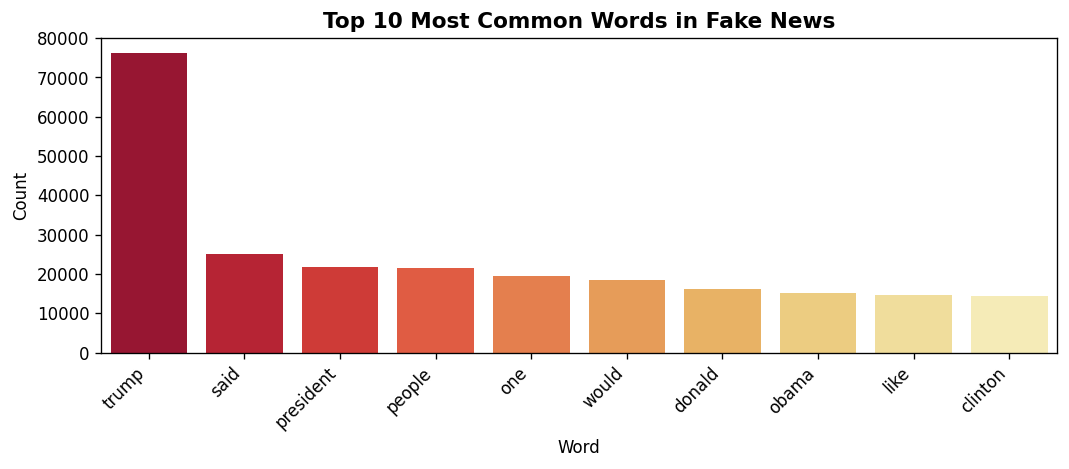

In [ ]:
# [Plot Top 10 Most Common Words in Fake News]
##                          Plotting the Most common words in fake news
sns.barplot(x="word", y="count", data=unigrams_fake, palette="YlOrRd_r")  # changed: Reds_r → YlOrRd_r
plt.title("Top 10 Most Common Words in Fake News")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# [Extract Top 10 Unigrams in Factual News]
##                                            most common unigrams for factual news after preprocessing
fact_news_tokens = sum(df[df.label ==1]["content"],[])
unigrams_fact = (pd.Series(nltk.ngrams(fact_news_tokens,1)).value_counts()).reset_index()[:10]
unigrams_fact.columns = ["word", "count"]
unigrams_fact

word,count
said,97828
trump,59585
would,31458
reuters,28787
president,28369
state,21440
government,18963
house,17905
new,17606
republican,16769


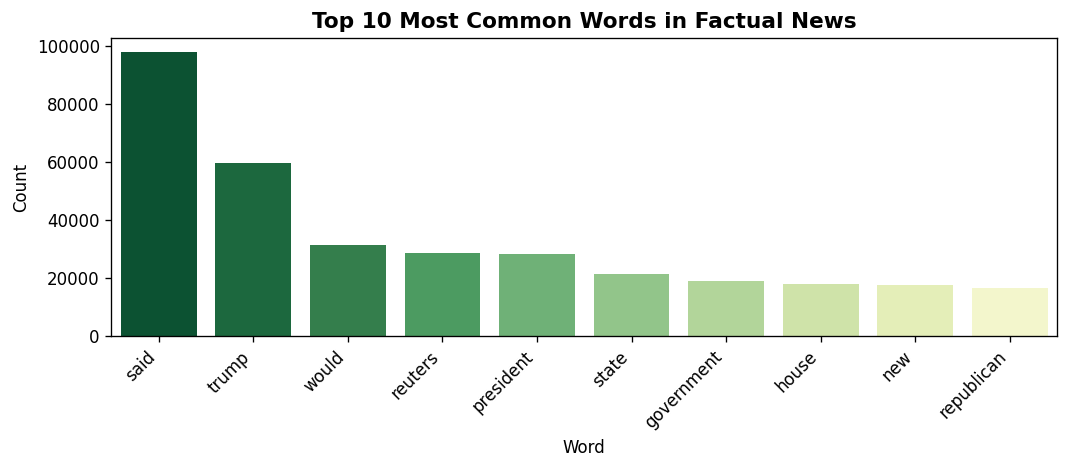

In [ ]:
# [Plot Top 10 Most Common Words in Factual News]
##                          Plotting the Most common words in factual news
sns.barplot(x="word", y="count", data=unigrams_fact, palette="YlGn_r")  
plt.title("Top 10 Most Common Words in Factual News")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Section 8 - Vectorization and Train-Test Split


In [28]:
# [Join Lemmatized Tokens Back to String]
# Join lemmatised tokens back into a string
df['content_str'] = df['content'].apply(lambda tokens: ' '.join(tokens))

In [29]:
# [Train-Test Split (80-20 Stratified)]
# Train / test split (80 / 20)
X = df['content_str']
y = df['label']

# Train / test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
# [TF-IDF Vectorization (Fit on Train Only)]
# TF-IDF vectorizer (fit only on training data to prevent data leakage)
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

In [31]:
# [Print Vectorized Shape Confirmation]
print(f'Train shape : {X_train_vec.shape}')
print(f'Test  shape : {X_test_vec.shape}')
print('Vectorization complete.')

Train shape : (30916, 50000)
Test  shape : (7730, 50000)
Vectorization complete.


## Section 9 - Model Training and Evaluation


In [32]:
# [Define Six ML Models for Comparison]
models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000, random_state=42),
    'Passive Aggressive'    : PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Naive Bayes'           : MultinomialNB(),
    'Decision Tree'         : DecisionTreeClassifier(random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Linear SVM'            : LinearSVC(max_iter=2000, random_state=42),
}

In [33]:
# [Train All Models and Evaluate Accuracy and F1 Score]
##                                                Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'f1': f1}
    print(f"{name:25s}  Accuracy={acc:.4f}  F1={f1:.4f}")

Logistic Regression        Accuracy=0.9873  F1=0.9885
Passive Aggressive         Accuracy=0.9942  F1=0.9947
Naive Bayes                Accuracy=0.9543  F1=0.9583
Decision Tree              Accuracy=0.9940  F1=0.9946
Random Forest              Accuracy=0.9924  F1=0.9931
Linear SVM                 Accuracy=0.9946  F1=0.9951


In [34]:
# [Select Best Model by F1 Score and Print Classification Report]
# Pick best model by F1
best_name  = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
print(f"\nBest Model: {best_name}")
print(classification_report(y_test, best_model.predict(X_test_vec), target_names=['Fake', 'Factual']))



Best Model: Linear SVM
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3491
     Factual       0.99      1.00      1.00      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



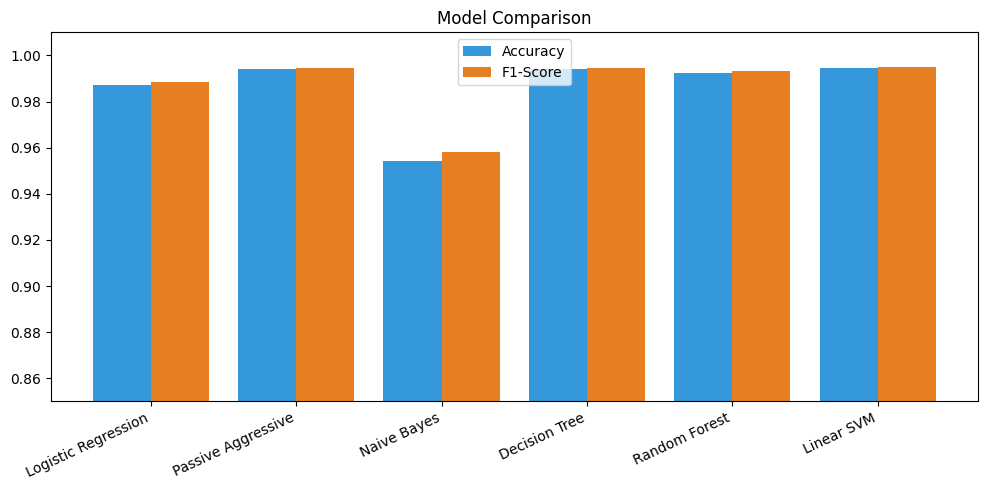

In [36]:
# [Plot Model Comparison Chart (Accuracy vs F1)]
##                                               Plot comparison
names  = list(results.keys())
f1s    = [results[n]['f1'] for n in names]
accs   = [results[n]['accuracy'] for n in names]
x = range(len(names))
plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x], accs, width=0.4, label='Accuracy', color='#3498DB') # changed: steelblue → #3498DB)
plt.bar([i + 0.2 for i in x], f1s,  width=0.4, label='F1-Score',  color='#E67E22' ) # changed: coral → #E67E22)
plt.xticks(x, names, rotation=25, ha='right')
plt.ylim(0.85, 1.01)
plt.title('Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# [Save Best Model and TF-IDF Vectorizer]
##                                      Save model and vectorizer
os.makedirs('model', exist_ok=True)
joblib.dump(best_model, 'model/best_model.pkl')
joblib.dump(tfidf,      'model/tfidf.pkl')
with open('model/best_model_name.txt', 'w') as f:
    f.write(best_name)
print("Saved to model/")

Saved to model/


## Section 10 - Streamlit Web Application


In [38]:
# [Streamlit App - Fake vs Factual News Detector UI]
# ##                                              STREAMLIT WEBSITE 

import re, joblib
import streamlit as st

model = joblib.load('model/best_model.pkl')
tfidf = joblib.load('model/tfidf.pkl')

st.title("Fake vs Factual News Detector")

title = st.text_input("Headline")
text  = st.text_area("Article Text", height=200)

if st.button("Analyze"):
    combined = f"{title} {text}".strip()
    if not combined:
        st.warning("Please enter some text.")
    else:
        cleaned = re.sub(r'\s+', ' ', re.sub(r'[^a-zA-Z\s]', ' ', combined.lower()))
        vec     = tfidf.transform([cleaned])
        pred    = model.predict(vec)[0]
        if pred == 1:
            st.success("FACTUAL NEWS")
        else:
            st.error("FAKE NEWS")

2026-05-30 00:03:55.429 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 00:03:55.748 
  command:

    streamlit run d:\Anaconda main\envs\llms_course_env\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-30 00:03:55.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 00:03:55.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 00:03:55.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 00:03:55.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 00:03:55.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-30 00:03:55.758 Thread 'Ma